# Wameed Project

## Preprocessing Phase

In [1]:
# import all libraries needed

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

### Read Dataset

In [2]:
# Define the path to the dataset
path_external = r"C:\Users\shaha\Desktop\CPIT-498\CPIT-499\TrainExternal.csv"
path_cali = r"C:\Users\shaha\Desktop\CPIT-498\CPIT-499\Saudi_Calibration.csv"
path_test = r"C:\Users\shaha\Desktop\CPIT-498\CPIT-499\Saudi_Test.csv"

# path_external = r"C:\Users\alhas\Downloads\TrainExternal.csv"
# path_cali = r"C:\Users\alhas\Downloads\Saudi_Calibration.csv"
# path_test = r"C:\Users\alhas\Downloads\Saudi_Test.csv"

# Read Wameed dataset
external = pd.read_csv(path_external)
cali = pd.read_csv(path_cali)
test = pd.read_csv(path_test)

In [3]:
# print the arizona and spain dataframe
external

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi
0,train_external,US,US_436.0_3904.0,1,1.0,2025-11-06 08:26:00,1762417560000,35.281333,-111.701014,US_-111.701014_35.281333_1762417560000,2414,6,198,9,7.157017,2.709646,0.000000,0.611016,0.545700,-0.525457
1,train_external,US,US_399.0_4043.0,1,1.0,2025-08-03 19:25:00,1754249100000,36.529991,-112.123222,US_-112.123222_36.529991_1754249100000,2558,1,24,10,20.038558,1.126099,0.000000,2.068330,0.555375,-0.501791
2,train_external,US,US_407.0_4017.0,1,2.0,2025-07-23 09:52:00,1753264320000,36.296429,-112.033391,US_-112.033391_36.296429_1753264320000,2732,1,202,10,19.110269,1.855883,0.000000,1.757434,0.421300,-0.305961
3,train_external,US,US_424.0_3923.0,1,2.0,2025-06-11 20:57:00,1749675420000,35.452013,-111.835761,US_-111.835761_35.452013_1749675420000,2295,2,345,10,24.238229,4.865652,0.000042,2.503880,0.310600,-0.424935
4,train_external,US,US_408.0_4032.0,1,2.0,2025-07-29 20:59:00,1753822740000,36.431176,-112.024408,US_-112.024408_36.431176_1753822740000,1915,4,77,7,25.220494,1.824639,0.000000,2.796168,0.308050,-0.372323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,train_external,ES,ES_425.0_4131.0,0,0.0,2025-07-08 12:27:00,1751977620000,37.327742,-3.843386,ES_-3.843386_37.327742_1751977620000,823,1,107,7,27.475824,1.106784,0.000000,2.212446,0.375450,-0.400832
446,train_external,ES,ES_358.0_4208.0,0,0.0,2025-09-20 12:40:00,1758372000000,38.014073,-4.608191,ES_-4.608191_38.014073_1758372000000,282,4,145,9,25.674463,1.358405,0.000000,1.664943,0.629267,-0.516001
447,train_external,ES,ES_182.0_4286.0,0,0.0,2024-08-11 14:12:00,1723385520000,38.665923,-6.645715,ES_-6.645715_38.665923_1723385520000,278,1,306,7,32.131301,0.580692,0.000000,3.004493,0.282400,-0.450616
448,train_external,ES,ES_483.0_4207.0,0,0.0,2025-10-09 13:25:00,1760016300000,38.011046,-3.193009,ES_-3.193009_38.011046_1760016300000,514,2,176,12,19.332351,0.815473,0.000030,0.661025,0.328450,-0.351122


In [4]:
# print the Saudi Calibration dataframe
cali

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi
0,sa_calibration,SA,SA_262.0_2012.0,1,2.0,2023-09-30 09:28:00,1696066080000,18.186393,42.755316,SA_42.755316_18.186393_1696066080000,2123,0,252,7,21.055709,1.343396,0.000000,1.987633,0.16565,-0.274478
1,sa_calibration,SA,SA_280.0_1937.0,1,1.0,2025-07-07 23:29:00,1751930940000,17.512656,42.934979,SA_42.934979_17.512656_1751930940000,1662,23,223,12,29.430419,1.096112,0.000000,2.368755,0.50680,-0.441386
2,sa_calibration,SA,SA_164.0_2123.0,1,1.0,2023-12-22 22:41:00,1703284860000,19.174540,41.812085,SA_41.812085_19.174540_1703284860000,381,3,262,16,25.209197,0.245394,0.000092,1.041998,0.16800,-0.235754
3,sa_calibration,SA,SA_260.0_1991.0,1,1.0,2025-06-11 10:45:00,1749638700000,17.997747,42.737350,SA_42.737350_17.997747_1749638700000,2411,14,237,9,29.884698,1.849636,0.000000,3.494928,0.39550,-0.365484
4,sa_calibration,SA,SA_224.0_2180.0,1,1.0,2024-12-18 22:56:00,1734562560000,19.704546,42.369040,SA_42.369040_19.704546_1734562560000,1363,7,253,16,16.691044,2.675359,0.000004,1.530108,0.09540,-0.179214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,sa_calibration,SA,SA_206.0_2039.0,0,0.0,2025-04-27 09:47:00,1745747220000,18.428854,42.218109,SA_42.218109_18.428854_1745747220000,926,4,196,7,27.557245,0.930360,0.000000,2.768713,0.20990,-0.282436
68,sa_calibration,SA,SA_190.0_2096.0,0,0.0,2025-10-11 11:00:00,1760180400000,18.936090,42.063154,SA_42.063154_18.936090_1760180400000,669,6,265,7,26.341679,1.333590,0.000000,2.795716,0.23030,-0.286933
69,sa_calibration,SA,SA_169.0_2065.0,0,0.0,2025-09-27 22:52:00,1759013520000,18.653466,41.866372,SA_41.866372_18.653466_1759013520000,359,4,277,16,30.992375,1.489549,0.000000,2.170597,0.16020,-0.230947
70,sa_calibration,SA,SA_176.0_2123.0,0,0.0,2025-10-02 22:59:00,1759445940000,19.176350,41.927334,SA_41.927334_19.176350_1759445940000,530,2,221,7,29.282953,0.572346,0.002355,1.202163,0.22150,-0.274269


In [5]:
# print first 5 rows of train external data
external.head()

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi
0,train_external,US,US_436.0_3904.0,1,1.0,2025-11-06 08:26:00,1762417560000,35.281333,-111.701014,US_-111.701014_35.281333_1762417560000,2414,6,198,9,7.157017,2.709646,0.000000,0.611016,0.545700,-0.525457
1,train_external,US,US_399.0_4043.0,1,1.0,2025-08-03 19:25:00,1754249100000,36.529991,-112.123222,US_-112.123222_36.529991_1754249100000,2558,1,24,10,20.038558,1.126099,0.000000,2.068330,0.555375,-0.501791
2,train_external,US,US_407.0_4017.0,1,2.0,2025-07-23 09:52:00,1753264320000,36.296429,-112.033391,US_-112.033391_36.296429_1753264320000,2732,1,202,10,19.110269,1.855883,0.000000,1.757434,0.421300,-0.305961
3,train_external,US,US_424.0_3923.0,1,2.0,2025-06-11 20:57:00,1749675420000,35.452013,-111.835761,US_-111.835761_35.452013_1749675420000,2295,2,345,10,24.238229,4.865652,0.000042,2.503880,0.310600,-0.424935
4,train_external,US,US_408.0_4032.0,1,2.0,2025-07-29 20:59:00,1753822740000,36.431176,-112.024408,US_-112.024408_36.431176_1753822740000,1915,4,77,7,25.220494,1.824639,0.000000,2.796168,0.308050,-0.372323


In [6]:
# print first 5 rows of train saudi calibration data
cali.head()

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi
0,sa_calibration,SA,SA_262.0_2012.0,1,2.0,2023-09-30 09:28:00,1696066080000,18.186393,42.755316,SA_42.755316_18.186393_1696066080000,2123,0,252,7,21.055709,1.343396,0.000000,1.987633,0.16565,-0.274478
1,sa_calibration,SA,SA_280.0_1937.0,1,1.0,2025-07-07 23:29:00,1751930940000,17.512656,42.934979,SA_42.934979_17.512656_1751930940000,1662,23,223,12,29.430419,1.096112,0.000000,2.368755,0.50680,-0.441386
2,sa_calibration,SA,SA_164.0_2123.0,1,1.0,2023-12-22 22:41:00,1703284860000,19.174540,41.812085,SA_41.812085_19.174540_1703284860000,381,3,262,16,25.209197,0.245394,0.000092,1.041998,0.16800,-0.235754
3,sa_calibration,SA,SA_260.0_1991.0,1,1.0,2025-06-11 10:45:00,1749638700000,17.997747,42.737350,SA_42.737350_17.997747_1749638700000,2411,14,237,9,29.884698,1.849636,0.000000,3.494928,0.39550,-0.365484
4,sa_calibration,SA,SA_224.0_2180.0,1,1.0,2024-12-18 22:56:00,1734562560000,19.704546,42.369040,SA_42.369040_19.704546_1734562560000,1363,7,253,16,16.691044,2.675359,0.000004,1.530108,0.09540,-0.179214


In [7]:
# print last 5 rows of train external data
external.tail()

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi
445,train_external,ES,ES_425.0_4131.0,0,0.0,2025-07-08 12:27:00,1751977620000,37.327742,-3.843386,ES_-3.843386_37.327742_1751977620000,823,1,107,7,27.475824,1.106784,0.00000,2.212446,0.375450,-0.400832
446,train_external,ES,ES_358.0_4208.0,0,0.0,2025-09-20 12:40:00,1758372000000,38.014073,-4.608191,ES_-4.608191_38.014073_1758372000000,282,4,145,9,25.674463,1.358405,0.00000,1.664943,0.629267,-0.516001
447,train_external,ES,ES_182.0_4286.0,0,0.0,2024-08-11 14:12:00,1723385520000,38.665923,-6.645715,ES_-6.645715_38.665923_1723385520000,278,1,306,7,32.131301,0.580692,0.00000,3.004493,0.282400,-0.450616
448,train_external,ES,ES_483.0_4207.0,0,0.0,2025-10-09 13:25:00,1760016300000,38.011046,-3.193009,ES_-3.193009_38.011046_1760016300000,514,2,176,12,19.332351,0.815473,0.00003,0.661025,0.328450,-0.351122
449,train_external,ES,ES_391.0_4192.0,0,0.0,2024-10-21 13:40:00,1729518000000,37.870556,-4.238245,ES_-4.238245_37.870556_1729518000000,326,1,231,7,19.298924,0.531509,0.00000,0.788766,0.316150,-0.364641


In [8]:
# print last 5 rows of train external data
cali.tail()

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi
67,sa_calibration,SA,SA_206.0_2039.0,0,0.0,2025-04-27 09:47:00,1745747220000,18.428854,42.218109,SA_42.218109_18.428854_1745747220000,926,4,196,7,27.557245,0.930360,0.000000,2.768713,0.2099,-0.282436
68,sa_calibration,SA,SA_190.0_2096.0,0,0.0,2025-10-11 11:00:00,1760180400000,18.936090,42.063154,SA_42.063154_18.936090_1760180400000,669,6,265,7,26.341679,1.333590,0.000000,2.795716,0.2303,-0.286933
69,sa_calibration,SA,SA_169.0_2065.0,0,0.0,2025-09-27 22:52:00,1759013520000,18.653466,41.866372,SA_41.866372_18.653466_1759013520000,359,4,277,16,30.992375,1.489549,0.000000,2.170597,0.1602,-0.230947
70,sa_calibration,SA,SA_176.0_2123.0,0,0.0,2025-10-02 22:59:00,1759445940000,19.176350,41.927334,SA_41.927334_19.176350_1759445940000,530,2,221,7,29.282953,0.572346,0.002355,1.202163,0.2215,-0.274269
71,sa_calibration,SA,SA_193.0_2023.0,0,0.0,2023-10-04 09:54:00,1696413240000,18.280690,42.101148,SA_42.101148_18.280690_1696413240000,842,3,342,10,26.285013,1.043605,0.000000,1.722567,0.2389,-0.250222


In [9]:
# print shape
print("The shape of external training data (Arizona, Spain) is:", external.shape)
print("The shape of Saudi calibrationing data is:", cali.shape)

The shape of external training data (Arizona, Spain) is: (450, 20)
The shape of Saudi calibrationing data is: (72, 20)


**Based on shape method we find that the number of instances is 522 (450 + 72) before cleaningand the number of attributes is 20**

In [10]:
external.groupby("label")["confidence_px"].mean()

label
0    0.000000
1    1.297778
Name: confidence_px, dtype: float64

In [11]:
cali.groupby("label")["confidence_px"].mean()

label
0    0.000000
1    1.102564
Name: confidence_px, dtype: float64

**The mean confidence value differs significantly between classes (0 for non-fire, >0 for fire), indicating potential data leakage; thus, it will be excluded from training.**

## Duplication

In [12]:
# show duplication of external training data
dup_rows_ext = external[external.duplicated(subset=None, keep='first')]
dup_rows_ext

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi


In [13]:
# show duplication of saudi training data
dup_rows_cali = cali[cali.duplicated(subset=None, keep='first')]
dup_rows_cali

,split,dataset_origin,cell_id,label,confidence_px,date,system_time_start,latitude,longitude,uid,elevation,slope,aspect,lulc,temperature,wind_speed,precipitation,vpd,ndvi,ndwi


**Based on the above result, the Wameed dataset has no duplicates**

## Attributes data type

In [14]:
# check data types
external.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   split              450 non-null    str    
 1   dataset_origin     450 non-null    str    
 2   cell_id            450 non-null    str    
 3   label              450 non-null    int64  
 4   confidence_px      450 non-null    float64
 5   date               450 non-null    str    
 6   system_time_start  450 non-null    int64  
 7   latitude           450 non-null    float64
 8   longitude          450 non-null    float64
 9   uid                450 non-null    str    
 10  elevation          450 non-null    int64  
 11  slope              450 non-null    int64  
 12  aspect             450 non-null    int64  
 13  lulc               450 non-null    int64  
 14  temperature        449 non-null    float64
 15  wind_speed         449 non-null    float64
 16  precipitation      449 non-null    fl

In [15]:
# check data types
cali.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   split              72 non-null     str    
 1   dataset_origin     72 non-null     str    
 2   cell_id            72 non-null     str    
 3   label              72 non-null     int64  
 4   confidence_px      72 non-null     float64
 5   date               72 non-null     str    
 6   system_time_start  72 non-null     int64  
 7   latitude           72 non-null     float64
 8   longitude          72 non-null     float64
 9   uid                72 non-null     str    
 10  elevation          72 non-null     int64  
 11  slope              72 non-null     int64  
 12  aspect             72 non-null     int64  
 13  lulc               72 non-null     int64  
 14  temperature        72 non-null     float64
 15  wind_speed         72 non-null     float64
 16  precipitation      72 non-null     floa

**The dataset contains a mix of categorical (object) and numerical (float64, int64) attributes but external training data has null data**

In [16]:
# check if there is -9999 which is represents a null data
(external == -9999).sum()

split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64

In [17]:
# check if there is -9999 which is represents a null data
(cali == -9999).sum()

split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64

**After deleting the null data, the number of instances is 521 (449 + 72)** 

### Check if dataset is Balanced

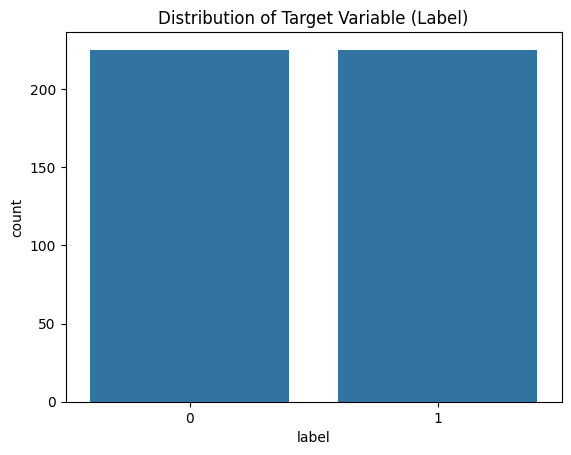

In [18]:
# Bar plot for target variable 'label' to check class distribution
sns.countplot(x=external["label"])
plt.title("Distribution of Target Variable (Label)")
plt.show()

In [19]:
# Count the number of fire vs. non-fire samples
external["label"].value_counts()

label
1    225
0    225
Name: count, dtype: int64

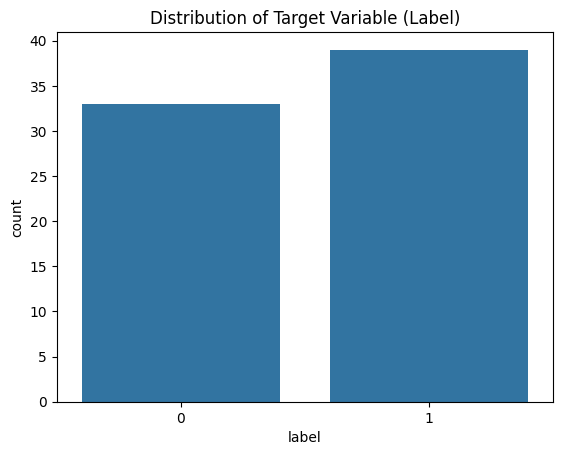

In [20]:
# Bar plot for target variable 'label' to check class distribution
sns.countplot(x=cali["label"])
plt.title("Distribution of Target Variable (Label)")
plt.show()

In [21]:
# Count the number of fire vs. non-fire samples
cali["label"].value_counts()

label
1    39
0    33
Name: count, dtype: int64

**Based on the result, we can observe the distribution of our target classes (Fire vs. No Fire)**

In [22]:
# # Check sample counts for each split
# print("Split counts:", data["split"].value_counts())

# # Check sample counts for each origin
# print("\nOrigin counts:", data["dataset_origin"].value_counts())

In [23]:
# ensure data 
external["dataset_origin"].value_counts()

dataset_origin
US    300
ES    150
Name: count, dtype: int64

**External dataset includes only US and ES samples.**

In [24]:
set(cali["uid"]).intersection(set(test["uid"]))

set()

**No overlap exists between Saudi calibration and Saudi test sets.**

## Outlier Detection

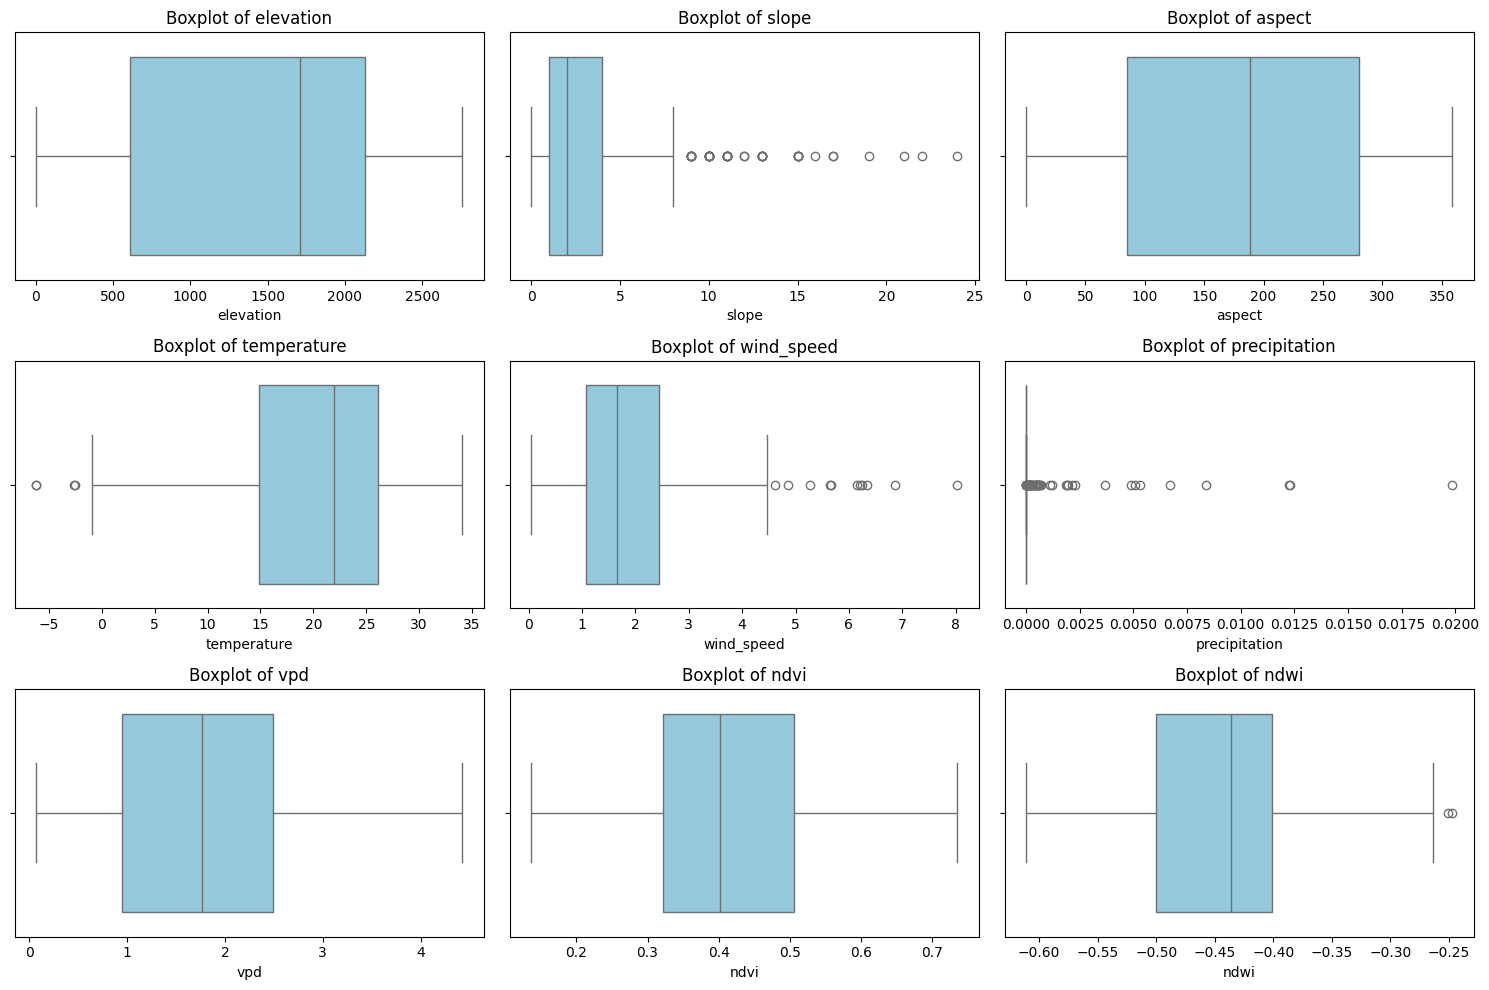

In [25]:
# Select numerical columns
numeric_cols = ['elevation', 'slope', 'aspect', 'temperature', 'wind_speed', 'precipitation', 'vpd', 'ndvi', 'ndwi']

# Plot Boxplots for each numerical feature
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=external[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

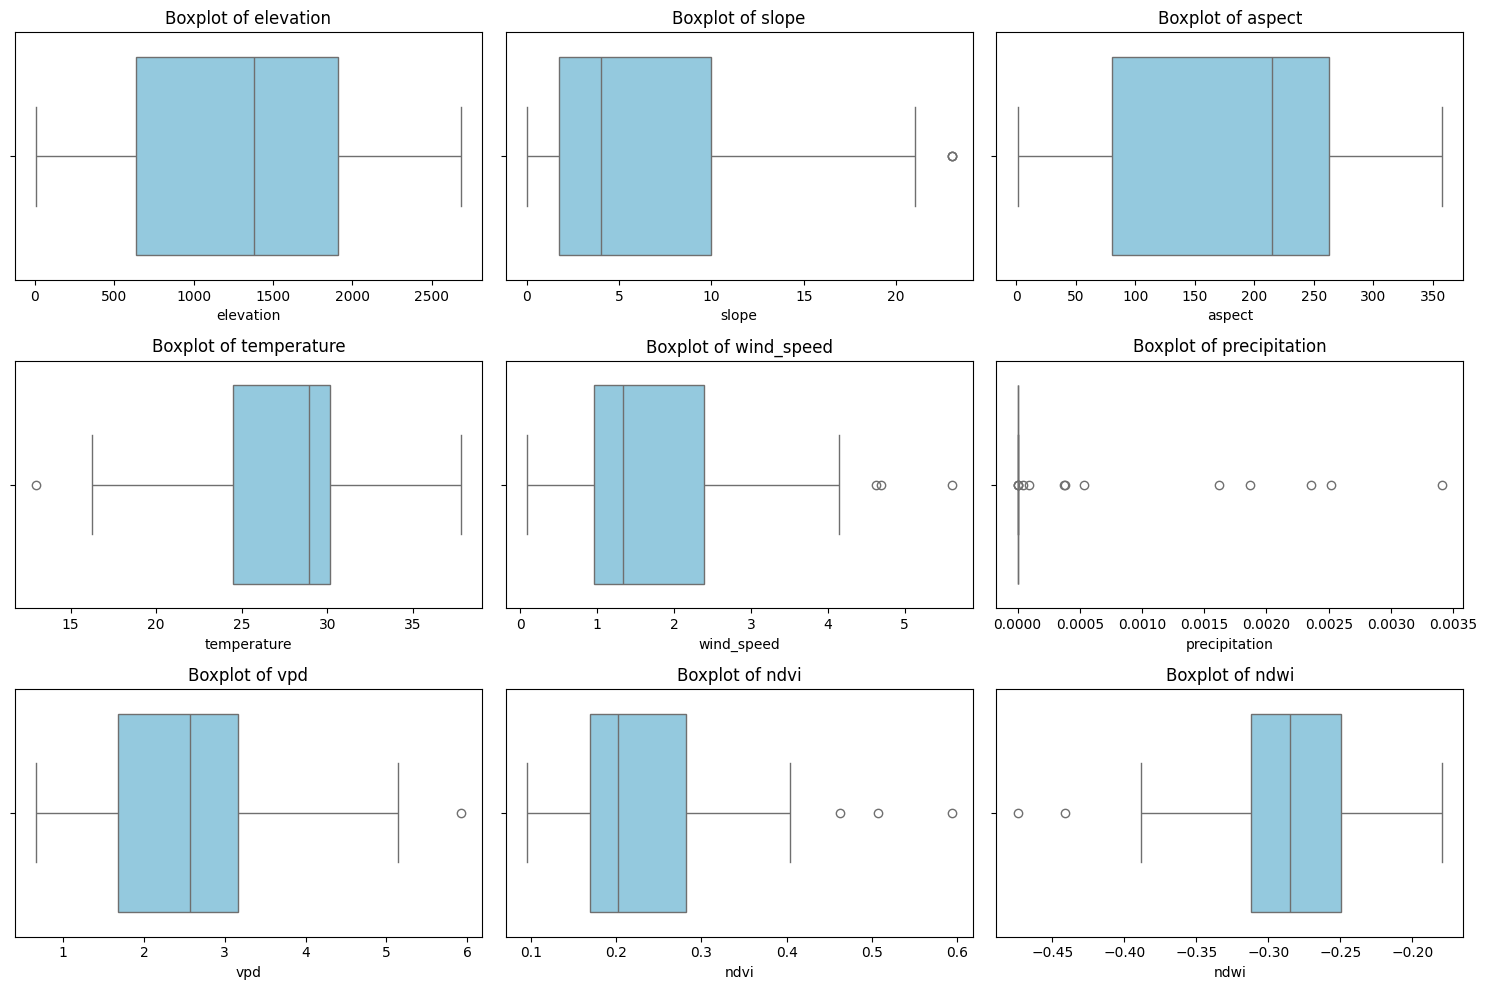

In [26]:
# Select numerical columns
numeric_cols = ['elevation', 'slope', 'aspect', 'temperature', 'wind_speed', 'precipitation', 'vpd', 'ndvi', 'ndwi']

# Plot Boxplots for each numerical feature
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=cali[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

**Extreme environmental values were kept because they reflect real wildfire conditions.**

## Missing Values

In [27]:
# Check for missing values in the External training dataset
external.isnull().sum(axis=0)

split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          1
wind_speed           1
precipitation        1
vpd                  1
ndvi                 0
ndwi                 0
dtype: int64

In [28]:
# Check for missing values in the Saudi Calibration dataset
cali.isnull().sum(axis=0)

split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64

In [29]:
# Missing values represent by (unknown, or ?) in the External training dataset
print("Check for 'unknown':")
print((external == 'unknown').sum())

print("\nCheck for '?':")
print((external == '?').sum())

Check for 'unknown':
split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64

Check for '?':
split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64


In [30]:
# Missing values represent by (unknown, or ?) in the Saudi Calibration dataset
print("Check for 'unknown':")
print((cali == 'unknown').sum())

print("\nCheck for '?':")
print((cali == '?').sum())

Check for 'unknown':
split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64

Check for '?':
split                0
dataset_origin       0
cell_id              0
label                0
confidence_px        0
date                 0
system_time_start    0
latitude             0
longitude            0
uid                  0
elevation            0
slope                0
aspect               0
lulc                 0
temperature          0
wind_speed           0
precipitation        0
vpd                  0
ndvi                 0
ndwi                 0
dtype: int64


**Based on the above results, external training datasets contain 3 null values.**

### Dropping Unnecessary Columns

In [31]:
# Drop columns that can cause data leakage
cols_to_drop = ['uid', 'cell_id', 'confidence_px', 'date', 'system_time_start', 'latitude', 'longitude', 'split', 'dataset_origin']

# Create a clean dataframe by dropping these columns
external_clean = external.drop(columns=cols_to_drop, errors='ignore')
cali_clean = cali.drop(columns=cols_to_drop, errors='ignore')
test_clean = test.drop(columns=cols_to_drop, errors='ignore') 

# Verify the remaining columns
print("Remaining columns:")
display(external_clean.columns.tolist())

Remaining columns:


['label',
 'elevation',
 'slope',
 'aspect',
 'lulc',
 'temperature',
 'wind_speed',
 'precipitation',
 'vpd',
 'ndvi',
 'ndwi']

## Correlation Matrix

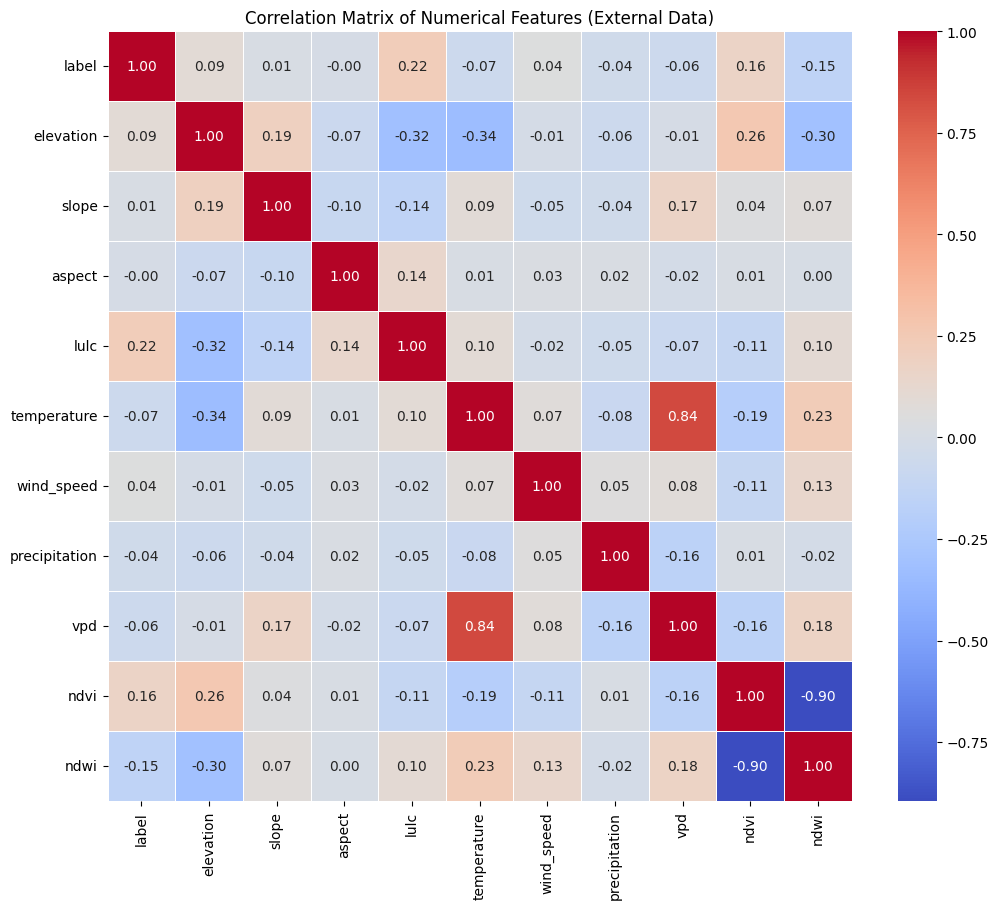

In [32]:
# Correlation Matrix Heatmap for numerical features in external dataset
plt.figure(figsize=(12, 10))

# Select only numerical columns for correlation
numeric_cols = external_clean.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = external_clean[numeric_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features (External Data)")
plt.show()

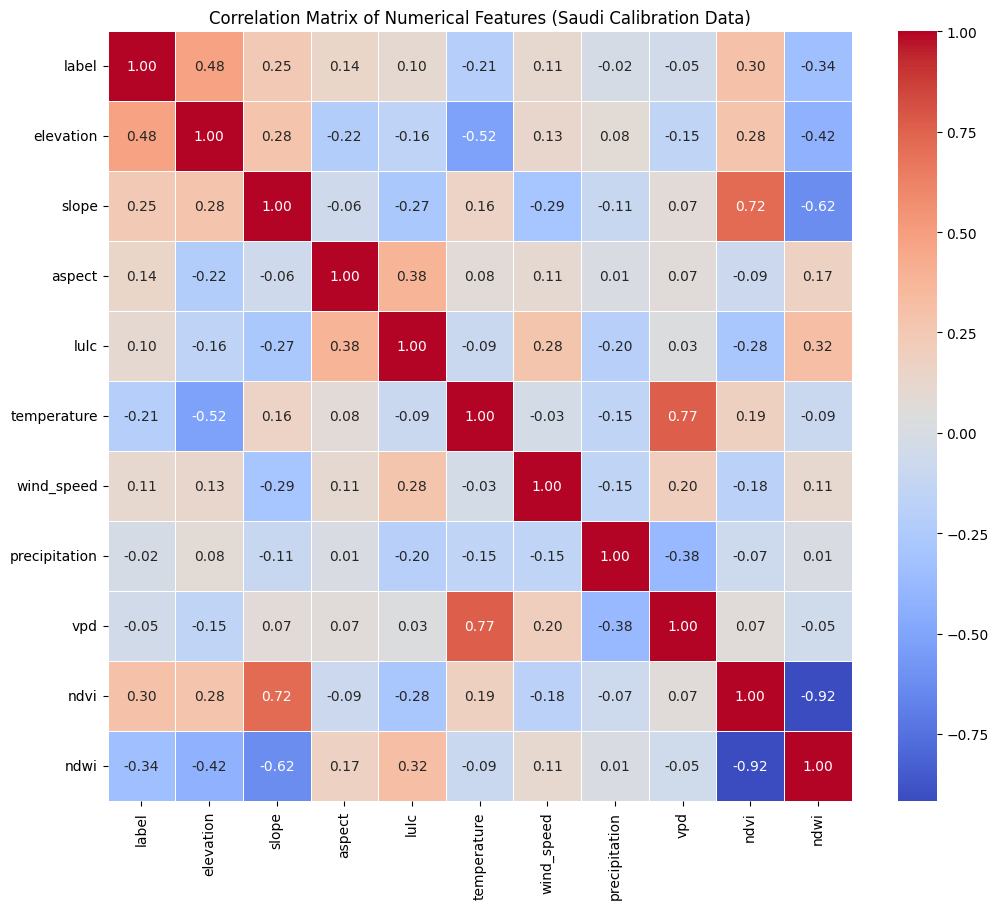

In [33]:
# Correlation Matrix Heatmap for numerical features in Saudi Calibration dataset
plt.figure(figsize=(12, 10))

# Select only numerical columns for correlation
numeric_cols = cali_clean.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = cali_clean[numeric_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features (Saudi Calibration Data)")
plt.show()

**The correlation analysis revealed no strong linear relationship between any individual feature and the wildfire label.
However, strong inter-feature correlations were observed between NDVI and NDWI, and between Temperature and VPD. 
Therefore, four feature configurations will be evaluated to assess the impact of feature redundancy on model performance.**

### Feature Reduction Based on Correlation

In [34]:
# Create four feature configurations based on correlation analysis

# 1) Baseline version (keep all cleaned features)
external_base = external_clean.copy()
cali_base = cali_clean.copy()

# 2) Remove NDWI
external_no_ndwi = external_clean.drop(columns=['ndwi'], errors='ignore')
cali_no_ndwi = cali_clean.drop(columns=['ndwi'], errors='ignore')

# 3) Remove VPD
external_no_vpd = external_clean.drop(columns=['vpd'], errors='ignore')
cali_no_vpd = cali_clean.drop(columns=['vpd'], errors='ignore')

# 4) Remove both NDWI and VPD
external_no_ndwi_vpd = external_clean.drop(columns=['ndwi', 'vpd'], errors='ignore')
cali_no_ndwi_vpd = cali_clean.drop(columns=['ndwi', 'vpd'], errors='ignore')

print("Four feature configurations were created successfully.")

Four feature configurations were created successfully.


**Based on the correlation analysis, four feature configurations were created to evaluate the effect of redundant features on model performance: a baseline version, a version without NDWI, a version without VPD, and a version without both NDWI and VPD.**

### Separating Features (X) and Target (y) & Preprocessing Pipeline (Imputation and Scaling)

The target variable is `label`
1. **Impute** missing values (Median for numbers, Mode for categories).
2. **Scale** numerical features using StandardScaler.
3. **Encode** categorical features using OneHotEncoder.

In [35]:
# Store all feature configurations in one dictionary
configurations = {
    "baseline": (external_base, cali_base),
    "no_ndwi": (external_no_ndwi, cali_no_ndwi),
    "no_vpd": (external_no_vpd, cali_no_vpd),
    "no_ndwi_vpd": (external_no_ndwi_vpd, cali_no_ndwi_vpd)
}

# Dictionary to store all processed outputs
processed_configs = {}

# Loop through each configuration
for config_name, (train_df, cal_df) in configurations.items():
    
    print(f"\n--- {config_name.upper()} CONFIGURATION ---")
    
    # 1) Separate Features (X) and Target (y)
    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    
    X_cal = cal_df.drop(columns=['label'])
    y_cal = cal_df['label']
    
    print("Features and target separated successfully.")
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)
    print("X_cal shape  :", X_cal.shape)
    print("y_cal shape  :", y_cal.shape)

    # 2) Define the available numerical and categorical features
    all_numeric_features = [
        'elevation', 'slope', 'aspect', 'temperature',
        'wind_speed', 'precipitation', 'vpd', 'ndvi', 'ndwi'
    ]
    
    numeric_features = [col for col in all_numeric_features if col in X_train.columns]
    categorical_features = [col for col in ['lulc'] if col in X_train.columns]
    
    print("Numerical features used:", numeric_features)
    print("Categorical features used:", categorical_features)

    # 3) Build the preprocessing pipeline
    
    # Numerical pipeline:
    # - Fill missing numerical values using median
    # - Standardize numerical features
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical pipeline:
    # - Fill missing categorical values using most frequent value
    # - Convert categories into one-hot encoded columns
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])

    # Build transformers dynamically
    transformers_list = []

    if numeric_features:
        transformers_list.append(('num', numeric_transformer, numeric_features))

    if categorical_features:
        transformers_list.append(('cat', categorical_transformer, categorical_features))

    # Combine both pipelines into a single ColumnTransformer
    preprocessor = ColumnTransformer(transformers=transformers_list)

    # 4) Apply transformations
    X_train_processed = preprocessor.fit_transform(X_train)
    X_cal_processed = preprocessor.transform(X_cal)

    # 5) Get feature names after preprocessing
    feature_names = preprocessor.get_feature_names_out()

    # 6) Convert arrays back to DataFrames
    X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
    X_cal_final = pd.DataFrame(X_cal_processed, columns=feature_names, index=X_cal.index)

    # 8) Save each processed configuration separately
    processed_configs[config_name] = {
        "X_train": X_train_final,
        "y_train": y_train,
        "X_cal": X_cal_final,
        "y_cal": y_cal,
        "preprocessor": preprocessor,
        "feature_names": feature_names
    }


--- BASELINE CONFIGURATION ---
Features and target separated successfully.
X_train shape: (450, 10)
y_train shape: (450,)
X_cal shape  : (72, 10)
y_cal shape  : (72,)
Numerical features used: ['elevation', 'slope', 'aspect', 'temperature', 'wind_speed', 'precipitation', 'vpd', 'ndvi', 'ndwi']
Categorical features used: ['lulc']

--- NO_NDWI CONFIGURATION ---
Features and target separated successfully.
X_train shape: (450, 9)
y_train shape: (450,)
X_cal shape  : (72, 9)
y_cal shape  : (72,)
Numerical features used: ['elevation', 'slope', 'aspect', 'temperature', 'wind_speed', 'precipitation', 'vpd', 'ndvi']
Categorical features used: ['lulc']

--- NO_VPD CONFIGURATION ---
Features and target separated successfully.
X_train shape: (450, 9)
y_train shape: (450,)
X_cal shape  : (72, 9)
y_cal shape  : (72,)
Numerical features used: ['elevation', 'slope', 'aspect', 'temperature', 'wind_speed', 'precipitation', 'ndvi', 'ndwi']
Categorical features used: ['lulc']

--- NO_NDWI_VPD CONFIGURATIO

In [36]:
# Check missing values in external training data
baseline_train = processed_configs["baseline"]["X_train"]
print("The total of null values in each feature:")
print(baseline_train.isnull().sum(axis=0))
print("\nTotal missing in baseline train:", baseline_train.isnull().sum().sum())

The total of null values in each feature:
num__elevation        0
num__slope            0
num__aspect           0
num__temperature      0
num__wind_speed       0
num__precipitation    0
num__vpd              0
num__ndvi             0
num__ndwi             0
cat__lulc_6           0
cat__lulc_7           0
cat__lulc_8           0
cat__lulc_9           0
cat__lulc_10          0
cat__lulc_12          0
cat__lulc_13          0
cat__lulc_16          0
cat__lulc_17          0
dtype: int64

Total missing in baseline train: 0


**After applying median imputation to the training data, no missing values remained in the processed dataset.**

## Model Trainning & Evaluation Phase

### Prepare data for trainning

In [37]:
config = processed_configs["baseline"] # choose baseline
preprocessor = config["preprocessor"]

# split test data to X, Y
X_test = test_clean.drop("label", axis=1)
y_test = test_clean["label"]

# same preprocessing to x test data
X_test = preprocessor.transform(X_test)

In [38]:
# prepare trainning data
# Arizona, Spain
X_train = config["X_train"]
y_train = config["y_train"]

# Saudi data
X_cal = config["X_cal"]
y_cal = config["y_cal"]

In [39]:
# Merge External and Saudi data
X_full = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_cal)], axis=0)
y_full = pd.concat([pd.Series(y_train), pd.Series(y_cal)], axis=0)

# Organize data
X_full = X_full.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

X_test = pd.DataFrame(X_test, columns=X_full.columns).reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)

### Trainning and Evaluation

### Random Forest Model

In [40]:
# import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# ------ Random Forest ----------
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
) # num of trees, fixed results every time, balance classes

# train 
rf_model.fit(X_full, y_full)

# best threshold after trying
best_threshold = 0.35

# predict for test data (probailities)
proba_fire = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (proba_fire >= best_threshold).astype(int) # convert y into 0, 1 based on threshold

# evaluation
print("Threshold:", best_threshold)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Threshold: 0.35
Confusion Matrix:
[[18 24]
 [ 5 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.43      0.55        42
           1       0.56      0.86      0.68        36

    accuracy                           0.63        78
   macro avg       0.67      0.64      0.62        78
weighted avg       0.68      0.63      0.61        78



## XGBoost Model

In [41]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [42]:
from xgboost import XGBClassifier

# Handle Class Imbalance
neg = (y_full == 0).sum()
pos = (y_full == 1).sum()
scale_pos_weight = neg / pos if pos != 0 else 1

# Initialize XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

# Train Model
xgb_model.fit(X_full, y_full)

# Predict Probabilities
proba_fire = xgb_model.predict_proba(X_test)[:, 1]

# Threshold Optimization
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
best = None

for t in thresholds:
    y_pred = (proba_fire >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall_fire = tp / (tp + fn) if (tp + fn) else 0
    f1_fire = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0

    print(f"\n--- threshold={t} ---")
    print("Confusion Matrix:\n", [[tn, fp],[fn, tp]])
    print("Recall(Fire)=", round(recall_fire, 3), " | F1(Fire)=", round(f1_fire, 3))

    score = (recall_fire, f1_fire)
    if best is None or score > best["score"]:
        best = {"t": t, "y_pred": y_pred, "score": score}

# Final Evaluation
print("\n========================")
print("Best threshold:", best["t"])
print("Best (Recall, F1):", best["score"])
print("========================\n")

y_pred_xgb = best["y_pred"]

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))


--- threshold=0.25 ---
Confusion Matrix:
 [[np.int64(23), np.int64(19)], [np.int64(7), np.int64(29)]]
Recall(Fire)= 0.806  | F1(Fire)= 0.69

--- threshold=0.3 ---
Confusion Matrix:
 [[np.int64(27), np.int64(15)], [np.int64(9), np.int64(27)]]
Recall(Fire)= 0.75  | F1(Fire)= 0.692

--- threshold=0.35 ---
Confusion Matrix:
 [[np.int64(27), np.int64(15)], [np.int64(10), np.int64(26)]]
Recall(Fire)= 0.722  | F1(Fire)= 0.675

--- threshold=0.4 ---
Confusion Matrix:
 [[np.int64(29), np.int64(13)], [np.int64(12), np.int64(24)]]
Recall(Fire)= 0.667  | F1(Fire)= 0.658

--- threshold=0.45 ---
Confusion Matrix:
 [[np.int64(30), np.int64(12)], [np.int64(13), np.int64(23)]]
Recall(Fire)= 0.639  | F1(Fire)= 0.648

--- threshold=0.5 ---
Confusion Matrix:
 [[np.int64(30), np.int64(12)], [np.int64(13), np.int64(23)]]
Recall(Fire)= 0.639  | F1(Fire)= 0.648

Best threshold: 0.25
Best (Recall, F1): (np.float64(0.8055555555555556), np.float64(0.6904761904761905))

Final Confusion Matrix:
[[23 19]
 [ 7 29]]

## Gradient Boost Model

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train Model
gb_model.fit(X_full, y_full)

# Predict Probabilities
proba_fire = gb_model.predict_proba(X_test)[:, 1]

# Threshold Optimization
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
best = None

for t in thresholds:
    y_pred = (proba_fire >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall_fire = tp / (tp + fn) if (tp + fn) else 0
    f1_fire = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0

    print(f"\n--- threshold={t} ---")
    print("Confusion Matrix:\n", [[tn, fp],[fn, tp]])
    print("Recall(Fire)=", round(recall_fire, 3), " | F1(Fire)=", round(f1_fire, 3))

    score = (recall_fire, f1_fire)  # اختيار الأفضل: Recall ثم F1
    if best is None or score > best["score"]:
        best = {"t": t, "y_pred": y_pred, "score": score}

# Final Evaluation
print("\n========================")
print("Best threshold:", best["t"])
print("Best (Recall, F1):", best["score"])
print("========================\n")

y_pred_gb = best["y_pred"]

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))


--- threshold=0.25 ---
Confusion Matrix:
 [[np.int64(19), np.int64(23)], [np.int64(4), np.int64(32)]]
Recall(Fire)= 0.889  | F1(Fire)= 0.703

--- threshold=0.3 ---
Confusion Matrix:
 [[np.int64(22), np.int64(20)], [np.int64(6), np.int64(30)]]
Recall(Fire)= 0.833  | F1(Fire)= 0.698

--- threshold=0.35 ---
Confusion Matrix:
 [[np.int64(23), np.int64(19)], [np.int64(8), np.int64(28)]]
Recall(Fire)= 0.778  | F1(Fire)= 0.675

--- threshold=0.4 ---
Confusion Matrix:
 [[np.int64(29), np.int64(13)], [np.int64(9), np.int64(27)]]
Recall(Fire)= 0.75  | F1(Fire)= 0.711

--- threshold=0.45 ---
Confusion Matrix:
 [[np.int64(31), np.int64(11)], [np.int64(12), np.int64(24)]]
Recall(Fire)= 0.667  | F1(Fire)= 0.676

--- threshold=0.5 ---
Confusion Matrix:
 [[np.int64(31), np.int64(11)], [np.int64(13), np.int64(23)]]
Recall(Fire)= 0.639  | F1(Fire)= 0.657

--- threshold=0.55 ---
Confusion Matrix:
 [[np.int64(34), np.int64(8)], [np.int64(19), np.int64(17)]]
Recall(Fire)= 0.472  | F1(Fire)= 0.557

Best th

**based on trying the three models we found that RandomForest was the best because it has the highest Recall 0.92 which mean it find 92 fires from 100 fires which is the most important metric for saftey system, Precision= 0.57 it has some false alerts, F1=70, Accuracy=0.64**

## Feature Ablation

#### (NO_NDWI)

In [44]:
config_no_ndwi = processed_configs["no_ndwi"]
preprocessor_no_ndwi = config_no_ndwi["preprocessor"]

# TEST data
X_test_no_ndwi = test_clean.drop("label", axis=1)
y_test_no_ndwi = test_clean["label"]
X_test_no_ndwi = preprocessor_no_ndwi.transform(X_test_no_ndwi)

# TRAIN data
X_train_no_ndwi = config_no_ndwi["X_train"]
y_train_no_ndwi = config_no_ndwi["y_train"]
X_cal_no_ndwi = config_no_ndwi["X_cal"]
y_cal_no_ndwi = config_no_ndwi["y_cal"]


# Merge data
X_full_no_ndwi = pd.concat(
    [pd.DataFrame(X_train_no_ndwi), pd.DataFrame(X_cal_no_ndwi)],
    axis=0
)
y_full_no_ndwi = pd.concat(
    [pd.Series(y_train_no_ndwi), pd.Series(y_cal_no_ndwi)],
    axis=0
)

# reset index
X_full_no_ndwi = X_full_no_ndwi.reset_index(drop=True)
y_full_no_ndwi = y_full_no_ndwi.reset_index(drop=True)

# align test
X_test_no_ndwi = pd.DataFrame(X_test_no_ndwi, columns=X_full_no_ndwi.columns).reset_index(drop=True)
y_test_no_ndwi = pd.Series(y_test_no_ndwi).reset_index(drop=True)

# Random Forest
rf_model_no_ndwi = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train
rf_model_no_ndwi.fit(X_full_no_ndwi, y_full_no_ndwi)

# Predict probabilities
proba_fire_no_ndwi_rf = rf_model_no_ndwi.predict_proba(X_test_no_ndwi)[:, 1]

# Threshold
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
best_no_ndwi_rf = None

# trying different thresholds and choose the best
for t in thresholds:
    y_pred_no_ndwi_rf = (proba_fire_no_ndwi_rf >= t).astype(int) # if probability highest than threshold its 1

    tn, fp, fn, tp = confusion_matrix(y_test_no_ndwi, y_pred_no_ndwi_rf).ravel() # compute results
    recall_fire = tp / (tp + fn) if (tp + fn) else 0
    f1_fire = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0 # calculate recall+F1

    # print results for each threshold
    print(f"\n--- NO_NDWI RF threshold={t} ---")
    print("Confusion Matrix:\n", [[tn, fp], [fn, tp]])
    print("Recall(Fire)=", round(recall_fire, 3), " | F1(Fire)=", round(f1_fire, 3))

    score = (recall_fire, f1_fire)
    # save best threshold
    if best_no_ndwi_rf is None or score > best_no_ndwi_rf["score"]: # compare scores
        best_no_ndwi_rf = {"t": t, "y_pred": y_pred_no_ndwi_rf, "score": score} # save the best

# Final Evaluation
print("\n")
print("Best threshold (NO_NDWI RF):", best_no_ndwi_rf["t"])
print("Best (Recall, F1):", best_no_ndwi_rf["score"])
print("\n")

y_pred_final_no_ndwi_rf = best_no_ndwi_rf["y_pred"]

print("Final Confusion Matrix (NO_NDWI RF):")
print(confusion_matrix(y_test_no_ndwi, y_pred_final_no_ndwi_rf))

print("\nFinal Classification Report (NO_NDWI RF):")
print(classification_report(y_test_no_ndwi, y_pred_final_no_ndwi_rf, zero_division=0))


--- NO_NDWI RF threshold=0.25 ---
Confusion Matrix:
 [[np.int64(9), np.int64(33)], [np.int64(1), np.int64(35)]]
Recall(Fire)= 0.972  | F1(Fire)= 0.673

--- NO_NDWI RF threshold=0.3 ---
Confusion Matrix:
 [[np.int64(13), np.int64(29)], [np.int64(4), np.int64(32)]]
Recall(Fire)= 0.889  | F1(Fire)= 0.66

--- NO_NDWI RF threshold=0.35 ---
Confusion Matrix:
 [[np.int64(21), np.int64(21)], [np.int64(7), np.int64(29)]]
Recall(Fire)= 0.806  | F1(Fire)= 0.674

--- NO_NDWI RF threshold=0.4 ---
Confusion Matrix:
 [[np.int64(23), np.int64(19)], [np.int64(8), np.int64(28)]]
Recall(Fire)= 0.778  | F1(Fire)= 0.675

--- NO_NDWI RF threshold=0.45 ---
Confusion Matrix:
 [[np.int64(29), np.int64(13)], [np.int64(9), np.int64(27)]]
Recall(Fire)= 0.75  | F1(Fire)= 0.711

--- NO_NDWI RF threshold=0.5 ---
Confusion Matrix:
 [[np.int64(32), np.int64(10)], [np.int64(13), np.int64(23)]]
Recall(Fire)= 0.639  | F1(Fire)= 0.667

--- NO_NDWI RF threshold=0.55 ---
Confusion Matrix:
 [[np.int64(35), np.int64(7)], [np

#### (NO_VPD)

In [45]:

# Prepare data (NO_VPD)
config_no_vpd = processed_configs["no_vpd"]
preprocessor_no_vpd = config_no_vpd["preprocessor"]

# test
X_test_no_vpd_raw = test_clean.drop("label", axis=1)
y_test_no_vpd = test_clean["label"]

# make test cloumns as train columns
expected_cols_no_vpd = preprocessor_no_vpd.feature_names_in_
X_test_no_vpd_raw = X_test_no_vpd_raw.reindex(columns=expected_cols_no_vpd)

X_test_no_vpd = preprocessor_no_vpd.transform(X_test_no_vpd_raw)

# train + cal
X_train_no_vpd = config_no_vpd["X_train"]
y_train_no_vpd = config_no_vpd["y_train"]
X_cal_no_vpd = config_no_vpd["X_cal"]
y_cal_no_vpd = config_no_vpd["y_cal"]

X_full_no_vpd = pd.concat([X_train_no_vpd, X_cal_no_vpd], axis=0).reset_index(drop=True)
y_full_no_vpd = pd.concat([y_train_no_vpd, y_cal_no_vpd], axis=0).reset_index(drop=True)

# align test columns
X_test_no_vpd = pd.DataFrame(X_test_no_vpd, columns=X_full_no_vpd.columns).reset_index(drop=True)
y_test_no_vpd = pd.Series(y_test_no_vpd).reset_index(drop=True)

# Train RF
rf_model_no_vpd = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model_no_vpd.fit(X_full_no_vpd, y_full_no_vpd)

proba_fire_no_vpd = rf_model_no_vpd.predict_proba(X_test_no_vpd)[:, 1]


# Threshold tuning
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
best_no_vpd = None

for t in thresholds:
    y_pred_no_vpd = (proba_fire_no_vpd >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_no_vpd, y_pred_no_vpd).ravel()

    recall_fire = tp / (tp + fn) if (tp + fn) else 0
    f1_fire = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0

    print(f"\n--- NO_VPD RF threshold={t} ---")
    print("Confusion Matrix:\n", [[tn, fp], [fn, tp]])
    print("Recall(Fire)=", round(recall_fire, 3), " | F1(Fire)=", round(f1_fire, 3))

    score = (recall_fire, f1_fire)
    if best_no_vpd is None or score > best_no_vpd["score"]:
        best_no_vpd = {"t": t, "y_pred": y_pred_no_vpd, "score": score}

print("\n")
print("Best threshold (NO_VPD RF):", best_no_vpd["t"])
print("Best (Recall, F1):", best_no_vpd["score"])
print("\n")

y_pred_final_no_vpd = best_no_vpd["y_pred"]

print("Final Confusion Matrix (NO_VPD RF):")
print(confusion_matrix(y_test_no_vpd, y_pred_final_no_vpd))

print("\nFinal Classification Report (NO_VPD RF):")
print(classification_report(y_test_no_vpd, y_pred_final_no_vpd, zero_division=0))


--- NO_VPD RF threshold=0.25 ---
Confusion Matrix:
 [[np.int64(8), np.int64(34)], [np.int64(3), np.int64(33)]]
Recall(Fire)= 0.917  | F1(Fire)= 0.641

--- NO_VPD RF threshold=0.3 ---
Confusion Matrix:
 [[np.int64(10), np.int64(32)], [np.int64(3), np.int64(33)]]
Recall(Fire)= 0.917  | F1(Fire)= 0.653

--- NO_VPD RF threshold=0.35 ---
Confusion Matrix:
 [[np.int64(17), np.int64(25)], [np.int64(4), np.int64(32)]]
Recall(Fire)= 0.889  | F1(Fire)= 0.688

--- NO_VPD RF threshold=0.4 ---
Confusion Matrix:
 [[np.int64(25), np.int64(17)], [np.int64(7), np.int64(29)]]
Recall(Fire)= 0.806  | F1(Fire)= 0.707

--- NO_VPD RF threshold=0.45 ---
Confusion Matrix:
 [[np.int64(28), np.int64(14)], [np.int64(8), np.int64(28)]]
Recall(Fire)= 0.778  | F1(Fire)= 0.718

--- NO_VPD RF threshold=0.5 ---
Confusion Matrix:
 [[np.int64(31), np.int64(11)], [np.int64(14), np.int64(22)]]
Recall(Fire)= 0.611  | F1(Fire)= 0.638

--- NO_VPD RF threshold=0.55 ---
Confusion Matrix:
 [[np.int64(34), np.int64(8)], [np.int6

#### (NO_NDWI_VPD)

In [46]:

# Prepare data 
config_no_ndwi_vpd = processed_configs["no_ndwi_vpd"]
preprocessor_no_ndwi_vpd = config_no_ndwi_vpd["preprocessor"]

# test
X_test_no_ndwi_vpd_raw = test_clean.drop("label", axis=1)
y_test_no_ndwi_vpd = test_clean["label"]

# make test columns as train columns
expected_cols_no_ndwi_vpd = preprocessor_no_ndwi_vpd.feature_names_in_
X_test_no_ndwi_vpd_raw = X_test_no_ndwi_vpd_raw.reindex(columns=expected_cols_no_ndwi_vpd)

X_test_no_ndwi_vpd = preprocessor_no_ndwi_vpd.transform(X_test_no_ndwi_vpd_raw)

# train + cal
X_train_no_ndwi_vpd = config_no_ndwi_vpd["X_train"]
y_train_no_ndwi_vpd = config_no_ndwi_vpd["y_train"]
X_cal_no_ndwi_vpd = config_no_ndwi_vpd["X_cal"]
y_cal_no_ndwi_vpd = config_no_ndwi_vpd["y_cal"]

X_full_no_ndwi_vpd = pd.concat([X_train_no_ndwi_vpd, X_cal_no_ndwi_vpd], axis=0).reset_index(drop=True)
y_full_no_ndwi_vpd = pd.concat([y_train_no_ndwi_vpd, y_cal_no_ndwi_vpd], axis=0).reset_index(drop=True)

# align test columns
X_test_no_ndwi_vpd = pd.DataFrame(X_test_no_ndwi_vpd, columns=X_full_no_ndwi_vpd.columns).reset_index(drop=True)
y_test_no_ndwi_vpd = pd.Series(y_test_no_ndwi_vpd).reset_index(drop=True)


# Train RF 
rf_model_no_ndwi_vpd = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model_no_ndwi_vpd.fit(X_full_no_ndwi_vpd, y_full_no_ndwi_vpd)

proba_fire_no_ndwi_vpd = rf_model_no_ndwi_vpd.predict_proba(X_test_no_ndwi_vpd)[:, 1]


# Threshold tuning 
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
best_no_ndwi_vpd = None

for t in thresholds:
    y_pred_no_ndwi_vpd = (proba_fire_no_ndwi_vpd >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_no_ndwi_vpd, y_pred_no_ndwi_vpd).ravel()

    recall_fire = tp / (tp + fn) if (tp + fn) else 0
    f1_fire = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0

    print(f"\n--- NO_NDWI_VPD RF threshold={t} ---")
    print("Confusion Matrix:\n", [[tn, fp], [fn, tp]])
    print("Recall(Fire)=", round(recall_fire, 3), " | F1(Fire)=", round(f1_fire, 3))

    score = (recall_fire, f1_fire)
    if best_no_ndwi_vpd is None or score > best_no_ndwi_vpd["score"]:
        best_no_ndwi_vpd = {"t": t, "y_pred": y_pred_no_ndwi_vpd, "score": score}

print("\n")
print("Best threshold (NO_NDWI_VPD RF):", best_no_ndwi_vpd["t"])
print("Best (Recall, F1):", best_no_ndwi_vpd["score"])
print("\n")

y_pred_final_no_ndwi_vpd = best_no_ndwi_vpd["y_pred"]

print("Final Confusion Matrix (NO_NDWI_VPD RF):")
print(confusion_matrix(y_test_no_ndwi_vpd, y_pred_final_no_ndwi_vpd))

print("\nFinal Classification Report (NO_NDWI_VPD RF):")
print(classification_report(y_test_no_ndwi_vpd, y_pred_final_no_ndwi_vpd, zero_division=0))


--- NO_NDWI_VPD RF threshold=0.25 ---
Confusion Matrix:
 [[np.int64(11), np.int64(31)], [np.int64(3), np.int64(33)]]
Recall(Fire)= 0.917  | F1(Fire)= 0.66

--- NO_NDWI_VPD RF threshold=0.3 ---
Confusion Matrix:
 [[np.int64(15), np.int64(27)], [np.int64(4), np.int64(32)]]
Recall(Fire)= 0.889  | F1(Fire)= 0.674

--- NO_NDWI_VPD RF threshold=0.35 ---
Confusion Matrix:
 [[np.int64(19), np.int64(23)], [np.int64(4), np.int64(32)]]
Recall(Fire)= 0.889  | F1(Fire)= 0.703

--- NO_NDWI_VPD RF threshold=0.4 ---
Confusion Matrix:
 [[np.int64(25), np.int64(17)], [np.int64(7), np.int64(29)]]
Recall(Fire)= 0.806  | F1(Fire)= 0.707

--- NO_NDWI_VPD RF threshold=0.45 ---
Confusion Matrix:
 [[np.int64(27), np.int64(15)], [np.int64(11), np.int64(25)]]
Recall(Fire)= 0.694  | F1(Fire)= 0.658

--- NO_NDWI_VPD RF threshold=0.5 ---
Confusion Matrix:
 [[np.int64(29), np.int64(13)], [np.int64(13), np.int64(23)]]
Recall(Fire)= 0.639  | F1(Fire)= 0.639

--- NO_NDWI_VPD RF threshold=0.55 ---
Confusion Matrix:
 [[

**The results show that the baseline configuration (using all features) achieved the best overall performance, as it provides the most balanced results across precision, recall, and F1-score compared to the other configurations.**

## Save Random Forest Model

In [47]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")

best_threshold = 0.35
joblib.dump(best_threshold, "threshold.pkl")

config = processed_configs["baseline"]
preprocessor = config["preprocessor"]

joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']